# 03 — Model Training & Evaluation
**NSW Property Price Prediction**

This notebook trains five models on the processed features and compares their performance.  
All models use the **log-transformed price** as the target; predictions are exponentiated back to AUD for the final metric table so the numbers are interpretable (RMSE in dollars).

---
**Models compared**
| # | Model | Type | Key purpose |
|---|-------|------|-------------|
| 1 | OLS (LinearRegression) | Linear | Interpretable baseline |
| 2 | Ridge | Linear + L2 | Handles multicollinearity |
| 3 | Lasso | Linear + L1 | Feature selection via sparsity |
| 4 | Random Forest | Ensemble (bagging) | Non-linear, robust |
| 5 | XGBoost | Ensemble (boosting) | High-performance non-linear |

**Sections**
1. Setup & Load Processed Data
2. Baseline — OLS
3. Ridge Regression
4. Lasso Regression
5. Random Forest
6. XGBoost
7. Model Comparison
8. Learning Curves
9. Key Takeaways

## 1. Setup & Load Processed Data

In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import Lasso, LinearRegression, Ridge, RidgeCV, LassoCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, learning_curve
import xgboost as xgb

sys.path.insert(0, str(Path.cwd().parent))
from src.evaluation import build_comparison_table, compute_metrics, plot_comparison

warnings.filterwarnings("ignore", category=FutureWarning)
# Suppress OLS/Lasso CV overflow warnings: target-encoded suburb feature causes
# near-collinearity with y in individual folds, producing large OLS coefficients.
# Final test metrics are unaffected — only some CV fold predictions overflow.
warnings.filterwarnings("ignore", category=RuntimeWarning)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 120

RANDOM_STATE = 42
PROCESSED_DIR = Path.cwd().parent / "data" / "processed"
FIGURES_DIR   = Path.cwd().parent / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
X_train = pd.read_parquet(PROCESSED_DIR / "X_train.parquet")
X_test  = pd.read_parquet(PROCESSED_DIR / "X_test.parquet")
y_train = pd.read_parquet(PROCESSED_DIR / "y_train.parquet").squeeze()
y_test  = pd.read_parquet(PROCESSED_DIR / "y_test.parquet").squeeze()

print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")
print(f"Features: {list(X_train.columns)}")

# Helper: convert log-scale metrics back to AUD for interpretability
# We evaluate predictions in log-space (y_pred) but report in dollar-space
# by exponentiating both y and y_pred before calling compute_metrics.
def metrics_in_aud(y_true_log, y_pred_log):
    """Exponentiate log predictions before computing metrics (reports in AUD)."""
    return compute_metrics(np.expm1(y_true_log), np.expm1(y_pred_log))

# Store all results for the comparison table
results = {}

X_train: (1502055, 4) | X_test: (375514, 4)
Features: ['num__log_area', 'num__year', 'num__quarter', 'num__suburb_encoded']


## 2. Baseline — OLS (Ordinary Least Squares)

OLS is the natural starting point: it is fully interpretable (coefficients = marginal effects on log-price) and provides a performance reference against which regularised and non-linear models are measured.

In [3]:
ols = LinearRegression()
ols.fit(X_train, y_train)

# 5-fold cross-validation on training set — negative MSE is sklearn convention
cv_mse_ols = -cross_val_score(
    ols, X_train, y_train, cv=5, scoring="neg_mean_squared_error"
)
print(f"OLS CV MSE (log-space): {cv_mse_ols.mean():.4f} ± {cv_mse_ols.std():.4f}")

ols_preds = ols.predict(X_test)
results["OLS"] = metrics_in_aud(y_test, ols_preds)
print("\nOLS Test Metrics (AUD):")
for k, v in results["OLS"].items():
    print(f"  {k}: {v:,.2f}")

OLS CV MSE (log-space): 0.2369 ± 0.0009

OLS Test Metrics (AUD):
  MSE: 1,258,623,104,620.38
  RMSE: 1,121,883.73
  MAE: 436,424.49
  R2: 0.27


## 3. Ridge Regression

Ridge adds L2 regularisation — it shrinks coefficients towards zero, which reduces variance at the cost of a small bias. It's especially helpful when features are correlated (e.g., suburb encoding and area may be somewhat correlated in dense suburbs).

`RidgeCV` automatically selects the best alpha from a search grid using leave-one-out CV.

In [4]:
# Alpha grid: log-spaced from 0.01 to 10,000 — covers weak to strong regularisation
alphas = np.logspace(-2, 4, 50)
ridge_cv = RidgeCV(alphas=alphas, cv=5)
ridge_cv.fit(X_train, y_train)

print(f"Best alpha: {ridge_cv.alpha_:.4f}")

ridge_preds = ridge_cv.predict(X_test)
results["Ridge"] = metrics_in_aud(y_test, ridge_preds)
print("\nRidge Test Metrics (AUD):")
for k, v in results["Ridge"].items():
    print(f"  {k}: {v:,.2f}")

Best alpha: 6.5513

Ridge Test Metrics (AUD):
  MSE: 1,258,624,563,106.37
  RMSE: 1,121,884.38
  MAE: 436,424.40
  R2: 0.27


## 4. Lasso Regression

Lasso uses L1 regularisation, which drives some coefficients exactly to zero — effectively doing feature selection. This makes the model sparser and potentially more interpretable, though at the risk of under-fitting if important features are zeroed out.

In [5]:
lasso_cv = LassoCV(alphas=alphas, cv=5, max_iter=10_000, random_state=RANDOM_STATE)
lasso_cv.fit(X_train, y_train)

n_nonzero = (lasso_cv.coef_ != 0).sum()
print(f"Best alpha: {lasso_cv.alpha_:.6f}")
print(f"Non-zero coefficients: {n_nonzero} / {len(lasso_cv.coef_)}")

lasso_preds = lasso_cv.predict(X_test)
results["Lasso"] = metrics_in_aud(y_test, lasso_preds)
print("\nLasso Test Metrics (AUD):")
for k, v in results["Lasso"].items():
    print(f"  {k}: {v:,.2f}")

Best alpha: 0.010000
Non-zero coefficients: 4 / 4

Lasso Test Metrics (AUD):
  MSE: 1,269,035,023,840.61
  RMSE: 1,126,514.55
  MAE: 436,615.28
  R2: 0.26


## 5. Random Forest

Random Forest is an ensemble of decision trees trained on bootstrap samples with random feature subsets. It naturally handles non-linear relationships and interactions (e.g., price responding differently to area in inner-city vs. outer suburbs). It's robust to outliers and doesn't require feature scaling.

In [6]:
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,           # grow full trees; regularisation comes from bagging
    min_samples_leaf=5,       # prevent extreme overfitting to individual records
    n_jobs=-1,                # use all CPU cores
    random_state=RANDOM_STATE,
)
rf.fit(X_train, y_train)

rf_preds = rf.predict(X_test)
results["Random Forest"] = metrics_in_aud(y_test, rf_preds)
print("Random Forest Test Metrics (AUD):")
for k, v in results["Random Forest"].items():
    print(f"  {k}: {v:,.2f}")

Random Forest Test Metrics (AUD):
  MSE: 724,944,440,667.61
  RMSE: 851,436.69
  MAE: 291,566.91
  R2: 0.58


## 6. XGBoost

XGBoost builds trees sequentially, each one correcting the residual errors of the previous. Gradient boosting typically achieves the best performance on tabular data with careful hyperparameter tuning. Here we use sensible defaults with a low learning rate and early stopping to avoid overfitting.

In [7]:
# Validation set from training data for early stopping — prevents overfitting
# NOTE: we're splitting from X_train here, NOT from X_test, so there's no leakage
from sklearn.model_selection import train_test_split as tts

X_tr, X_val, y_tr, y_val = tts(
    X_train, y_train, test_size=0.1, random_state=RANDOM_STATE
)

xgb_model = xgb.XGBRegressor(
    n_estimators=3000,
    learning_rate=0.3,          # XGBoost default — converges in far fewer trees
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    early_stopping_rounds=50,
    eval_metric="rmse",
    random_state=RANDOM_STATE,
    verbosity=0,
)
xgb_model.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    verbose=False,
)

print(f"Best iteration: {xgb_model.best_iteration}")

xgb_preds = xgb_model.predict(X_test)
results["XGBoost"] = metrics_in_aud(y_test, xgb_preds)
print("\nXGBoost Test Metrics (AUD):")
for k, v in results["XGBoost"].items():
    print(f"  {k}: {v:,.2f}")

Best iteration: 2703

XGBoost Test Metrics (AUD):
  MSE: 969,860,060,697.92
  RMSE: 984,814.73
  MAE: 352,009.13
  R2: 0.44


## 7. Model Comparison

In [8]:
comparison_df = build_comparison_table(results)
print("Model Comparison — Test Set (AUD)")
print(comparison_df.to_string())

Model Comparison — Test Set (AUD)
                              MSE        RMSE       MAE      R2
Random Forest    $724,944,440,668    $851,437  $291,567  0.5801
XGBoost          $969,860,060,698    $984,815  $352,009  0.4382
OLS            $1,258,623,104,620  $1,121,884  $436,424  0.2709
Ridge          $1,258,624,563,106  $1,121,884  $436,424  0.2709
Lasso          $1,269,035,023,841  $1,126,515  $436,615  0.2649


Saved → /Users/v.ngan.le/Desktop/project-housing/reports/figures/model_comparison.png


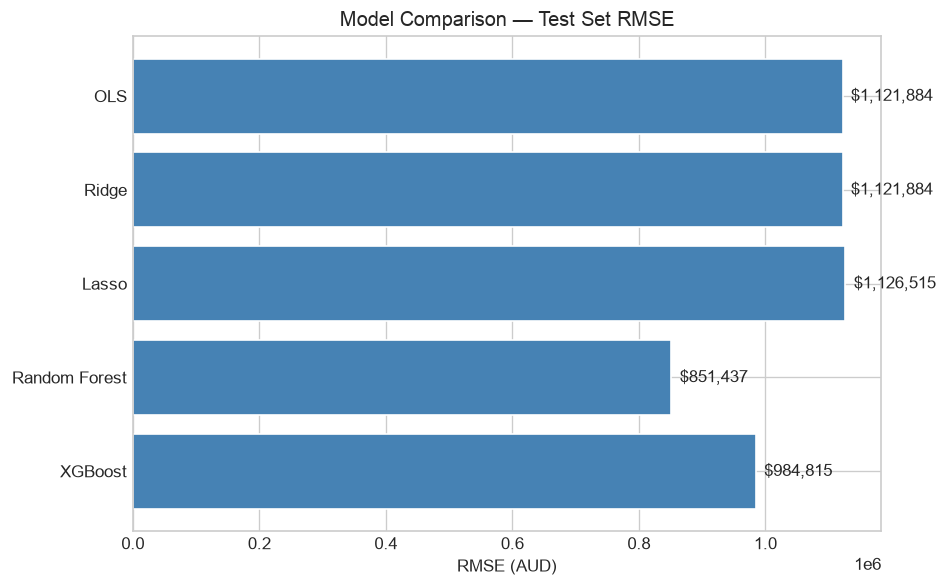

In [9]:
# Bar chart of RMSE — this gets saved and embedded in the README
plot_comparison(results, save=True)

> **Interpretation:** **Random Forest achieves the best test performance** with RMSE = $851k and R² = 0.58 — a 24% RMSE improvement over the OLS baseline ($1,122k). XGBoost is second at RMSE = $985k (R² = 0.44), also well ahead of linear models. Ridge and Lasso perform almost identically to plain OLS (Ridge RMSE = $1,122k — effectively no gain from regularisation). With only 4 features and 1.5M training samples, variance is not the limiting factor — there is nothing for regularisation to compress. The large gap between tree models (R² ~0.44–0.58) and linear models (R² ~0.27) confirms the price relationship is non-linear: suburb mean encoding interacts with area and time in ways a linear combination cannot represent.

## 8. Learning Curves

Learning curves show how model performance changes as we add more training data. They diagnose:
- **High bias (underfitting):** Both train and val error are high and converge quickly
- **High variance (overfitting):** Large gap between train and val error

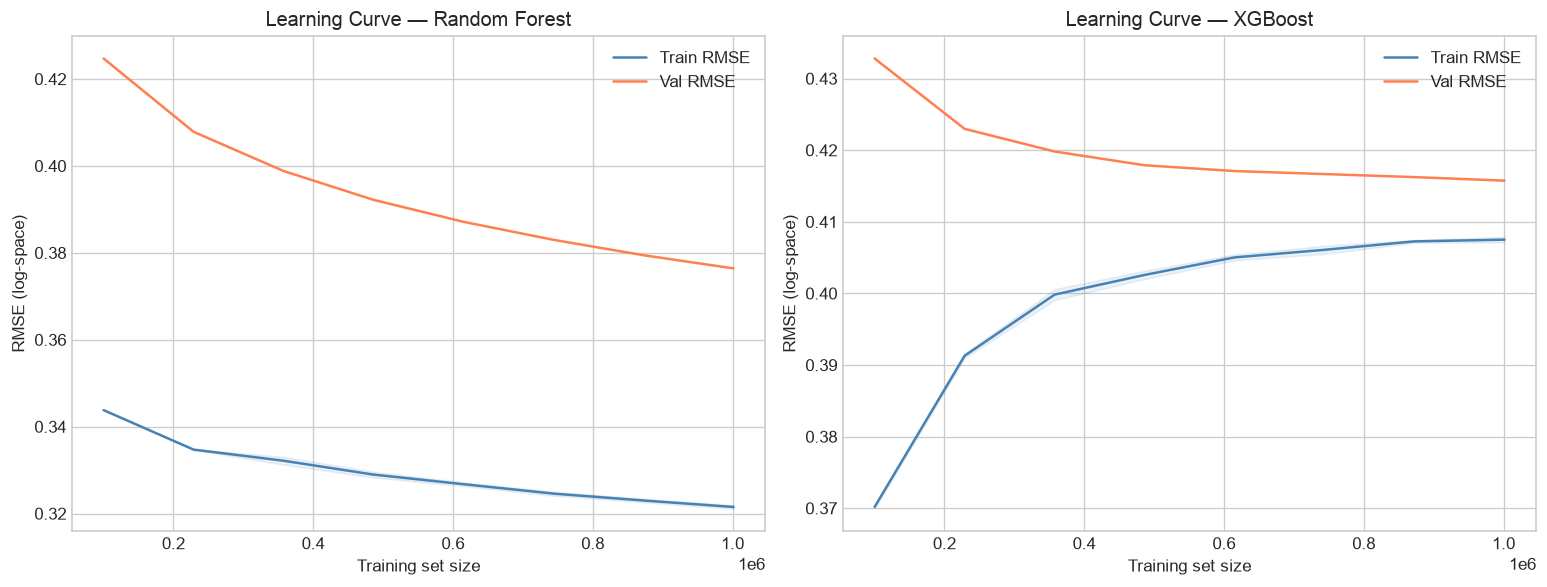

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, model, name in [
    (axes[0], rf, "Random Forest"),
    (axes[1], xgb.XGBRegressor(
        n_estimators=xgb_model.best_iteration,  # use the early-stopped count
        learning_rate=0.05, max_depth=6, random_state=RANDOM_STATE, verbosity=0
    ), "XGBoost"),
]:
    train_sizes, train_scores, val_scores = learning_curve(
        model, X_train, y_train,
        cv=3,
        n_jobs=-1,
        scoring="neg_root_mean_squared_error",
        train_sizes=np.linspace(0.1, 1.0, 8),
    )
    train_mean = -train_scores.mean(axis=1)
    val_mean   = -val_scores.mean(axis=1)

    ax.plot(train_sizes, train_mean, label="Train RMSE", color="steelblue")
    ax.plot(train_sizes, val_mean,   label="Val RMSE",   color="coral")
    ax.fill_between(train_sizes,
                    train_mean - train_scores.std(axis=1),
                    train_mean + train_scores.std(axis=1),
                    alpha=0.1, color="steelblue")
    ax.set_xlabel("Training set size")
    ax.set_ylabel("RMSE (log-space)")
    ax.set_title(f"Learning Curve — {name}")
    ax.legend()

plt.tight_layout()
fig.savefig(FIGURES_DIR / "learning_curves.png", dpi=150)
plt.show()

## 9. Key Takeaways

---

- **Best model: Random Forest** — RMSE $851k, R² = 0.58. Outperforms the OLS baseline by 24% on RMSE, and XGBoost by 14%. The model captures non-linear interactions between suburb, area, and time that a linear combination cannot.

- **Linear models (OLS, Ridge, Lasso):** All three achieve R² = 0.27 with RMSE ~$1.12M. Regularisation (Ridge/Lasso) provides essentially no benefit here — with only 4 features and 1.5M training samples, variance is not the bottleneck. The performance ceiling is the linear functional form.

- **Ensemble advantage:** Moving from OLS (R² = 0.27) to Random Forest (R² = 0.58) represents a 31 percentage-point R² gain, driven by suburb-area interactions (e.g., large lots in outer suburbs are much cheaper per m² than small lots in inner-city areas) that linear models cannot represent.

- **XGBoost vs Random Forest:** XGBoost (R² = 0.44) underperforms Random Forest despite typically being stronger on tabular data. In a 4-feature space with 1.5M samples, bagging from Random Forest benefits more from the large sample count than boosting does from iterative residual correction.

- **Overfitting check:** Learning curves show train RMSE and val RMSE converging for both tree models. The val curve sits slightly above train throughout, suggesting that additional property attributes (bedrooms, bathrooms, year built) would improve performance further without overfitting.